# Synthetic slant-delay estimation

Generate a dolphin-like whistle, extract its time-frequency contour from the
generated WAV, reconstruct an analytic template, and estimate the echo delay.


In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio, display
from scipy import signal
from scipy.io import wavfile

from orca import (
    ExperimentConfig,
    estimate_delay,
    extract_contours,
    synthetic_whistle,
    template_from_contour,
)


## Configuration


In [18]:
CONFIG = ExperimentConfig(
    sample_rate=24_001,
    duration_seconds=1,
    true_delay_seconds=0.02,
    noise_std=0.01,
    wav_path=Path("synthetic_dolphin_chirp.wav"),
    output_dir=Path("synthetic_dolphin_contours"),
    min_delay_seconds=0.002,
    max_delay_seconds=0.030,
)

contour_config = CONFIG.contour_config()
window_samples, nfft = contour_config.resolve_stft(CONFIG.sample_rate)
print(
    f"STFT window: {window_samples} samples "
    f"({window_samples / CONFIG.sample_rate * 1e3:.3f} ms); FFT: {nfft} points"
)


STFT window: 128 samples (5.333 ms); FFT: 2048 points


## Generate and save the experiment signal


In [19]:
time_seconds, target_frequency_hz, source = synthetic_whistle(
    duration_seconds=CONFIG.duration_seconds,
    sample_rate=CONFIG.sample_rate,
    start_hz=CONFIG.whistle_band_hz[0],
    end_hz=CONFIG.whistle_band_hz[1],
)

delay_samples = CONFIG.delay_samples
impulse_response = np.zeros(delay_samples + 1)
impulse_response[[0, delay_samples]] = [0.5, 0.2]
received = signal.convolve(source, impulse_response)
received += CONFIG.noise_std * np.random.default_rng(7).standard_normal(received.size)

pcm = np.int16(source / np.max(np.abs(source)) * np.iinfo(np.int16).max)
wavfile.write(CONFIG.wav_path, CONFIG.sample_rate, pcm)
display(Audio(source, rate=CONFIG.sample_rate, normalize=True))
print(
    f"Saved {CONFIG.wav_path} "
    f"({source.size} samples at {CONFIG.sample_rate} Hz)"
)


Saved synthetic_dolphin_chirp.wav (24001 samples at 24001 Hz)


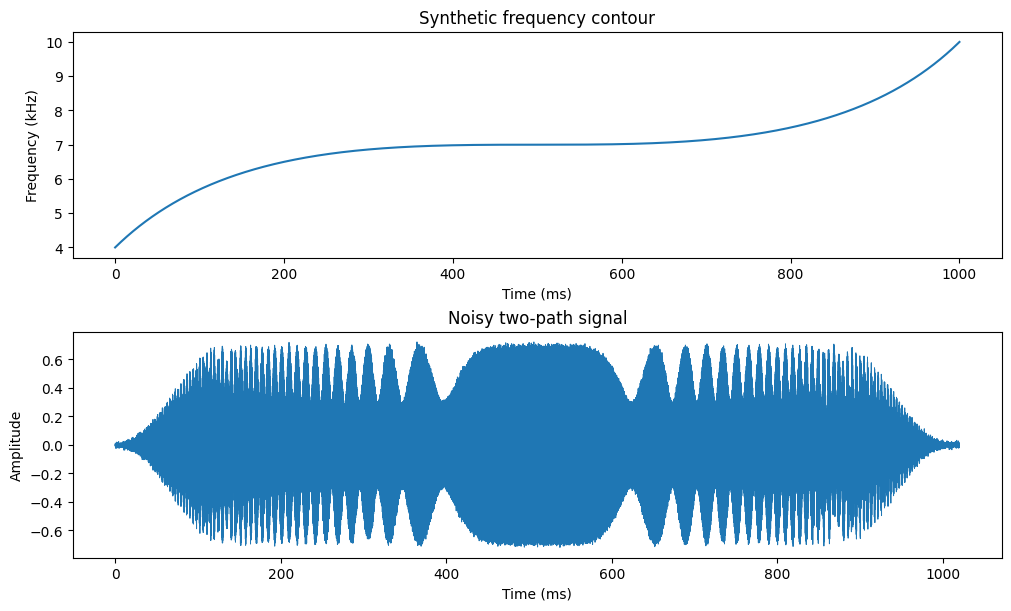

In [20]:
figure, axes = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True)
axes[0].plot(time_seconds * 1e3, target_frequency_hz / 1e3)
axes[0].set(title="Synthetic frequency contour", xlabel="Time (ms)", ylabel="Frequency (kHz)")
axes[1].plot(np.arange(received.size) / CONFIG.sample_rate * 1e3, received, linewidth=0.7)
axes[1].set(title="Noisy two-path signal", xlabel="Time (ms)", ylabel="Amplitude")
plt.show()


## Extract the contour and build the analytic template


In [21]:
extraction = extract_contours(
    CONFIG.wav_path,
    intervals=[(0.0, CONFIG.duration_seconds)],
    output_dir=CONFIG.output_dir,
    config=contour_config,
)
contour = next((item for item in extraction.contours if item.accepted), None)
if contour is None:
    raise RuntimeError("The supplied interval did not produce an accepted contour.")

template, fitted_frequency_hz = template_from_contour(
    contour,
    CONFIG.sample_rate,
    frequency_band_hz=CONFIG.whistle_band_hz,
)
print(f"Extracted {contour.time_seconds.size} points; confidence={contour.confidence:.2f}")
print(f"Artifacts: {extraction.output_dir}")


Extracted 1257 points; confidence=3.24
Artifacts: /Users/rbenjano/Desktop/Work/Orca_project/synthetic_dolphin_contours


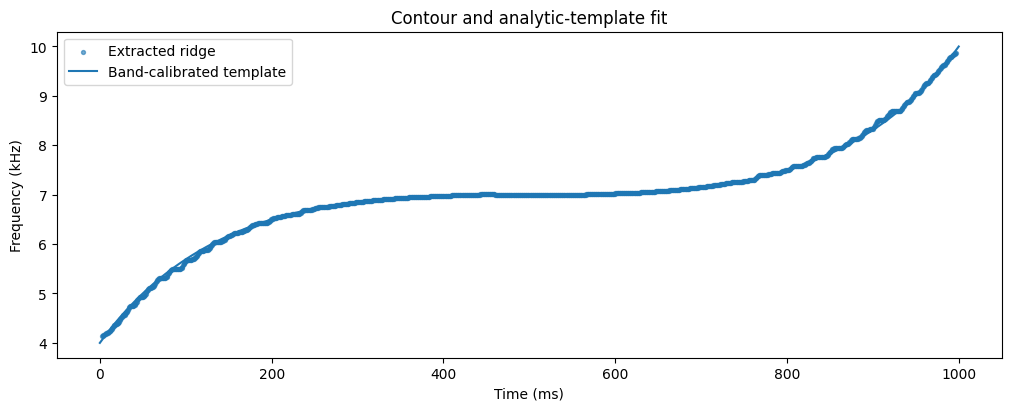

In [22]:
template_time = np.arange(template.size) / CONFIG.sample_rate
figure, axis = plt.subplots(figsize=(10, 4), constrained_layout=True)
axis.scatter(contour.time_seconds * 1e3, contour.frequency_hz / 1e3, s=8, alpha=0.6, label="Extracted ridge")
axis.plot(template_time * 1e3, fitted_frequency_hz / 1e3, label="Band-calibrated template")
axis.set(title="Contour and analytic-template fit", xlabel="Time (ms)", ylabel="Frequency (kHz)")
axis.legend()
plt.show()


## Estimate the delay


In [23]:
estimate = estimate_delay(
    received,
    template,
    CONFIG.sample_rate,
    min_delay_seconds=CONFIG.min_delay_seconds,
    max_delay_seconds=CONFIG.max_delay_seconds,
)
error_samples = abs(estimate.delay_samples - delay_samples)
error_seconds = abs(estimate.delay_seconds - CONFIG.true_delay_seconds)

print(
    f"True delay:      {delay_samples} samples = "
    f"{CONFIG.true_delay_seconds * 1e3:.3f} ms"
)
print(
    f"Estimated delay: {estimate.delay_samples} samples = "
    f"{estimate.delay_seconds * 1e3:.3f} ms"
)
print(f"Absolute error:  {error_samples} sample(s) = {error_seconds * 1e6:.1f} us")

assert error_seconds <= CONFIG.delay_error_tolerance_seconds, (
    f"Delay error {error_seconds * 1e6:.1f} us exceeds the configured "
    f"{CONFIG.delay_error_tolerance_seconds * 1e6:.1f} us tolerance."
)


True delay:      480 samples = 20.000 ms
Estimated delay: 479 samples = 19.958 ms
Absolute error:  1 sample(s) = 42.5 us


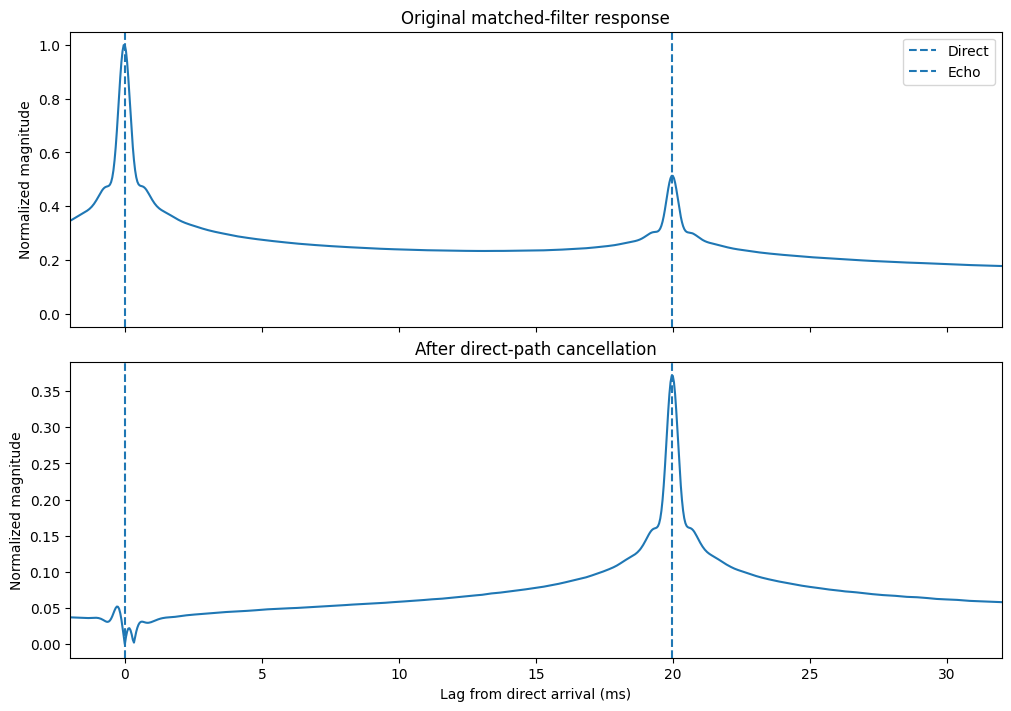

In [24]:
relative_lag_ms = (
    (estimate.lags - estimate.lags[estimate.direct_index])
    / CONFIG.sample_rate
    * 1e3
)
scale = np.abs(estimate.response).max()

figure, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
for axis, response, title in (
    (axes[0], estimate.response, "Original matched-filter response"),
    (axes[1], estimate.residual_response, "After direct-path cancellation"),
):
    axis.plot(relative_lag_ms, np.abs(response) / scale)
    for label, index in (("Direct", estimate.direct_index), ("Echo", estimate.echo_index)):
        axis.axvline(relative_lag_ms[index], linestyle="--", label=label)
    axis.set(ylabel="Normalized magnitude", title=title)

plot_margin_ms = max(1.0, CONFIG.min_delay_seconds * 1e3)
axes[0].legend()
axes[1].set(
    xlim=(-plot_margin_ms, CONFIG.max_delay_seconds * 1e3 + plot_margin_ms),
    xlabel="Lag from direct arrival (ms)",
)
plt.show()
